In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, confusion_matrix

## Load Data

In [4]:
def read_fasta(path):
    headers, sequences = [], []
    h, buf = None, []
    
    with open(path, 'r') as f:
        for line in f:
            if not line: 
                continue
            if line[0] == '>':
                if h is not None:
                    sequences.append(''.join(buf).upper())
                    buf = []
                h = line[1:].strip()
                headers.append(h)
            else:
                buf.append(line.strip())
        if h is not None:
            sequences.append(''.join(buf).upper())
            
    return headers, sequences

def load_labels(path):
    label_dict = {}
    with open(path, 'r') as f:
        for line in f:
            if not line:
                continue
            parts = line.strip().split('\t')
            header = parts[0][1:]
            if parts[1] == "None":
                label = 0.0
            else:
                label = 1.0
            label_dict[header] = label
    return label_dict

## Data Processing

In [5]:
# mapping ACGT to 0123
# mapping acgt to 0123
# mapping N and others to T

ENCODE = np.full(256, 4, dtype=np.int64)
for ch, idx in zip(b"ACGTNacgtn", [0, 1, 2, 3, 3, 0, 1, 2, 3, 3]):
    ENCODE[ch] = idx

# reverse complement ACGTN -> TGCAN -> 32104
REV_COMP = torch.tensor([3, 2, 1, 0, 4]) 

In [6]:
class SeqDataset(Dataset):
    def __init__(self, headers, sequences, labels):
        self.headers = headers
        self.sequences = sequences
        self.labels = np.asarray(labels, dtype=np.float32)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.headers[idx], self.sequences[idx].encode('ascii', 'ignore'), self.labels[idx]

In [7]:
def collate_pad(batch):
    headers, seq_bytes, labels = zip(*batch)
    idx_list = [ENCODE[np.frombuffer(sb, dtype=np.uint8)] for sb in seq_bytes]
    max_length = max(x.size for x in idx_list)
    batch_size = len(idx_list)
    
    X = torch.zeros(batch_size, 5, max_length, dtype=torch.float32)   # channels: A, C, G, T, N
    mask = torch.zeros(batch_size, max_length, dtype=torch.bool)      # padding mask
    
    for i, idx_np in enumerate(idx_list):
        length = idx_np.size
        idx = torch.from_numpy(idx_np).long()
        X[i, idx, torch.arange(length)] = 1.0
        mask[i, :length] = (idx != 4)   # invalid positions: N or everything beyond the length
    
    Y = torch.tensor(labels, dtype=torch.float32)
    return headers, X, mask, Y

## CNN Network

In [8]:
# Reverse complement convolution layer
# input: one-hot (B, 5, L)
# output: RC-invariant feature map (B, C, L)

def rc_kernel(k: torch.Tensor):
    # Reverse complement the convolution kernel
    # k: (out_channels, in_channels, length)
    k_flip = k.flip(-1)
    return k_flip.index_select(1, REV_COMP.to(k.device))

class RCFirstConv1d(nn.Module):
    
    def __init__(self, out_channels, kernel_size=15, dilation=1, bias=True, dropout=0.1):
        super().__init__()
        assert kernel_size % 2 == 1
        pad = (kernel_size // 2) * dilation
        self.conv = nn.Conv1d(5, out_channels, kernel_size, padding=pad, dilation=dilation, bias=bias)
        self.batch_norm = nn.BatchNorm1d(out_channels)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        
        y1 = self.conv(x)             # (B, C, L)
        
        x_rc = x.flip(-1)[:, REV_COMP.to(x.device), :]
        y2 = self.conv(x_rc)          # (B, C, L)
        y2 = y2.flip(-1)
        
        y = torch.max(y1, y2)
        y = self.batch_norm(y)
        y = F.gelu(y)
        y = self.dropout(y)
        
        return y 

In [9]:
class ConvBlock(nn.Module):
    def __init__(self, c_in, c_out, kernel_size=9, dilation=1, dropout=0.1):
        super().__init__()
        pad = (kernel_size // 2) * dilation
        self.conv = nn.Conv1d(c_in, c_out, kernel_size, padding=pad, dilation=dilation)
        self.batch_norm = nn.BatchNorm1d(c_out)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        return self.dropout(F.gelu(self.batch_norm(self.conv(x))))

class MaskedMaxPool1d(nn.Module):
    def __init__(self, kernel_size=2, stride=2):
        super().__init__()
        self.kernel_size, self.stride = kernel_size, stride

    def forward(self, x, mask):  # x:(B, C, L), mask:(B, L)
        m = mask.unsqueeze(1)
        x_masked = x.masked_fill(~m, float('-inf'))
        y = F.max_pool1d(x_masked, self.kernel_size, self.stride)
        m_pooled = F.max_pool1d(m.float(), self.kernel_size, self.stride) > 0
        y = y.masked_fill(~m_pooled, 0.0)
        return y, m_pooled.squeeze(1)


In [10]:
class RCInputInvariantCNN(nn.Module):
    def __init__(self, width=64, motif_kernel = (9, 15, 21, ), context_kernel = 9, context_dilation = (1, 2, ), dropout=0.1):
        super().__init__()

        self.motif_conv_blocks = nn.ModuleList(
            RCFirstConv1d(width, kernel_size=ker, dilation=1, dropout=0.1)
            for ker in motif_kernel
        )
        dim = width * len(motif_kernel)

        self.context_blocks = nn.ModuleList()
        c_in = dim
        for dil in context_dilation:
            self.context_blocks.append(
                ConvBlock(c_in, width, kernel_size=context_kernel, dilation=dil, dropout=dropout)
            )
            c_in = width

        self.pool = MaskedMaxPool1d(kernel_size=2, stride=2)
        head_in_features = c_in

        self.head = nn.Sequential(
            nn.Linear(head_in_features, width),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(width, 1),
        )

    @staticmethod
    def masked_avg_pool(z, mask):
        if mask is None:
            return z.mean(-1)
        m = mask.unsqueeze(1).float()
        return (z * m).sum(-1) / m.sum(-1).clamp_min(1.0)

    def forward(self, x, mask):
        motif_outputs = [motif_conv(x) for motif_conv in self.motif_conv_blocks]
        z = torch.cat(motif_outputs, dim=1)

        for block in self.context_blocks:
            try:
                z = block(z) + z
            except RuntimeError:
                z = block(z)
            z, mask = self.pool(z, mask)

        z_pooled_avg = self.masked_avg_pool(z, mask)
        out = self.head(z_pooled_avg).squeeze(-1)
        
        return out

## Train & Eval

In [11]:
def resolve_device(requested=None):
    """Return the best available accelerator as a torch.device."""
    if requested is not None:
        return torch.device(requested)
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

In [12]:
with torch.no_grad():
    device = resolve_device()
    model = RCInputInvariantCNN(width=16).to(device)
    X = torch.randn(3, 5, 64, device=device)
    mask = torch.zeros(3, 64, dtype=torch.bool, device=device)
    mask[0, :120] = True
    mask[1, :100] = True
    mask[2, :80] = True
    out = model(X, mask)
    print('Device:', device)
    print('Output shape:', out.shape)

Device: mps
Output shape: torch.Size([3])


In [13]:
def save_torch(data, path, filename): 
    os.makedirs(path, exist_ok=True)
    if os.path.exists("%s/%s.pt"%(path, filename)):
        n = 1
        while n <= 100:
            if os.path.exists("%s/%s_legend_%s.pt"%(path, filename, n)):
                n += 1
            else:
                torch.save(data, "%s/%s_legend_%s.pt"%(path, filename, n))
                break
    else:
        torch.save(data, "%s/%s.pt"%(path, filename))

In [14]:
def prepare_data(fasta_path, label_path, subset_size=None, random_state=42):
    headers, sequences = read_fasta(fasta_path)
    label_dict = load_labels(label_path)
    labels = [label_dict[h] for h in headers]
    
    total_sequences = len(sequences)
    if subset_size is not None and subset_size < total_sequences:
        rng = np.random.default_rng(random_state)
        perm = rng.permutation(total_sequences)
        sel_idx = np.sort(perm[:subset_size])
        headers = [headers[i] for i in sel_idx]
        sequences = [sequences[i] for i in sel_idx]
        labels = [labels[i] for i in sel_idx]
        print(f"Using random subset of {len(headers)} sequences (from {total_sequences}) with random_state={random_state}.")
    else:
        print(f"Using all {total_sequences} sequences for training.")

    idx_tr, idx_te = train_test_split(
        np.arange(len(sequences)), test_size=0.2, train_size=0.6, stratify=labels, random_state=42
    )
    idx_val = np.setdiff1d(np.arange(len(sequences)), np.concatenate([idx_tr, idx_te]))
    ds_tr = SeqDataset([headers[i] for i in idx_tr], [sequences[i] for i in idx_tr], [labels[i] for i in idx_tr])
    ds_val = SeqDataset([headers[i] for i in idx_te], [sequences[i] for i in idx_te], [labels[i] for i in idx_te])
    ds_te = SeqDataset([headers[i] for i in idx_val], [sequences[i] for i in idx_val], [labels[i] for i in idx_val])
    
    return ds_tr, ds_val, ds_te

In [15]:
def train_one_epoch(model, loader, opt, loss_fn, device, ep, epochs):
    model.train()
    total_loss = 0.0
    pbar = tqdm(loader, desc=f"Epoch {ep}/{epochs}", leave=False)
    for _, X, mask, Y in pbar:
        X, mask, Y = X.to(device), mask.to(device), Y.to(device)
        opt.zero_grad()
        logits = model(X, mask)
        loss = loss_fn(logits, Y)
        loss.backward()
        opt.step()
        total_loss += loss.item() * X.size(0)
        pbar.set_postfix(loss=f"{loss.item():.4f}")
    avg_loss = total_loss / len(loader.dataset)
    return avg_loss

def evaluate(model, loader, loss_fn, device, dataset):
    model.eval()
    val_running = 0.0
    all_logits = []
    all_labels = []
    with torch.no_grad():
        for _, X, mask, Y in tqdm(loader, desc="Val", leave=False):
            X, mask = X.to(device, dtype=torch.float32), mask.to(device)
            Y, logits = Y.to(device, dtype=torch.float32), model(X, mask)
            loss = loss_fn(logits, Y)
            val_running += loss.item() * X.size(0)
            all_logits.append(torch.sigmoid(logits).detach().cpu().numpy())
            all_labels.append(Y.detach().cpu().numpy())
    all_logits = np.concatenate(all_logits) if all_logits else np.array([])
    all_labels = np.concatenate(all_labels) if all_labels else np.array([])
    val_loss = val_running / len(dataset) if len(dataset) else float("nan")
    
    try:
        auroc = roc_auc_score(all_labels, all_logits)
        auprc = average_precision_score(all_labels, all_logits)
    except ValueError:
        auroc, auprc = float("nan"), float("nan")
    return auroc, auprc, val_loss, all_logits, all_labels

In [16]:
resolve_device(device)

device(type='mps')

In [ ]:
def run_train(fasta_path, label_path, batch_size=8, epochs=5, lr=1e-3, device=None, patience=10, subset_size=None, random_state=42, trial=False, pos_weight=None):
    device = resolve_device(device)
    print(f"Using device: {device}")

    ds_tr, ds_val, ds_te = prepare_data( fasta_path, label_path, subset_size=subset_size, random_state=random_state)
    loader_tr = DataLoader(ds_tr, batch_size=batch_size, shuffle=True, num_workers=0, collate_fn=collate_pad)
    loader_val = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=0, collate_fn=collate_pad)
    loader_te = DataLoader(ds_te, batch_size=batch_size, shuffle=False, num_workers=0, collate_fn=collate_pad)

    # The dataset is highly imbalanced; compute pos_weight if not provided
    if pos_weight is None:
        train_labels = torch.tensor(ds_tr.labels, dtype=torch.float32)
        pos_count = float(train_labels.sum().item())
        neg_count = float(train_labels.numel() - pos_count)
        if pos_count == 0:
            pos_weight_value = 1.0
        else:
            pos_weight_value = max(neg_count / pos_count, 1.0)
        print(f"Computed pos_weight={pos_weight_value:.4f} from dataset (pos={pos_count:.0f}, neg={neg_count:.0f})")
        pos_weight_tensor = torch.tensor(pos_weight_value, device=device)
    else:
        if isinstance(pos_weight, torch.Tensor):
            pos_weight_tensor = pos_weight.to(device)
            pos_weight_value = float(pos_weight_tensor.item())
        else:
            pos_weight_value = float(pos_weight)
            pos_weight_tensor = torch.tensor(pos_weight_value, device=device)
        print(f"Using provided pos_weight={pos_weight_value:.4f}")

    model = RCInputInvariantCNN().to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

    print("Starting training...")

    history = {"train_loss": [], "val_loss": [], "val_auroc": [], "val_auprc": []}
    best_state, best_epoch = None, None
    best_metrics = {"auroc": -float("inf"), "auprc": float("nan"), "val_loss": float("inf")}
    best_scores, best_labels = None, None
    last_scores, last_labels = None, None
    last_val_loss = None
    last_auroc, last_auprc = None, None
    bad = 0
    patience = patience if patience is not None else epochs + 1

    for ep in range(1, epochs + 1):
        train_loss = train_one_epoch(model, loader_tr, opt, loss_fn, device, ep, epochs)

        auroc, auprc, val_loss, Ps, Ys = evaluate(model, loader_val, loss_fn, device, ds_val)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_auroc"].append(auroc)
        history["val_auprc"].append(auprc)

        print(f"Epoch {ep}: train loss {train_loss:.4f} | Val loss {val_loss:.4f} | Val AUROC {auroc:.4f} | AUPRC {auprc:.4f}")

        last_scores, last_labels = Ps, Ys
        last_val_loss, last_auroc, last_auprc = val_loss, auroc, auprc

        improved = auroc > best_metrics["auroc"] + 1e-4
        if improved:
            best_metrics = {"auroc": auroc, "auprc": auprc, "val_loss": val_loss}
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_scores, best_labels, best_epoch = Ps, Ys, ep
            bad = 0
            torch.save(best_state, "vgp_model_data_tpase/rc_cnn_latest.pt")
        else:
            bad += 1
            if bad >= patience:
                print("Early stopping.")
                break
        if auroc == 1:
            print("Early stopping.")
            break

    if best_state is not None:
        if not trial:
            save_torch(best_state, "vgp_model_data_tpase", "rc_cnn_best")
            model.load_state_dict(best_state)
            model.to(device)
    else:
        best_scores, best_labels = last_scores, last_labels
        best_epoch = best_epoch if best_epoch is not None else len(history["train_loss"])
        best_metrics = {
            "auroc": last_auroc,
            "auprc": last_auprc,
            "val_loss": last_val_loss,
        }

    auroc, auprc, te_loss, te_scores, te_labels = evaluate(model, loader_te, loss_fn, device, ds_te)
    print(f"Test set performance: Loss {te_loss:.4f} | AUROC {auroc:.4f} | AUPRC {auprc:.4f}")

    results = {
        "model": model,
        "history": history,
        "metrics": {
            "best_epoch": best_epoch,
            "best_auroc": best_metrics["auroc"],
            "best_auprc": best_metrics["auprc"],
            "best_val_loss": best_metrics["val_loss"],
            "test_auroc": auroc,
            "test_auprc": auprc,
            "test_loss": te_loss,
        },
        "roc": {
            "labels": te_labels,
            "scores": te_scores,
            "best_labels": best_labels,
            "best_scores": best_scores,
        },
        "device": str(device),
        "pos_weight": pos_weight_value,
    }
    return results

In [44]:
fasta_path = '../data/vgp/all_vgp_tes.fa'
label_path = '../data/vgp/features-tpase.txt'
subset_size = 6000  # set to None to use the full dataset
subset_seed = 42

headers, sequences = read_fasta(fasta_path)
label_dict = load_labels(label_path)
labels = [label_dict[h] for h in headers]

In [47]:
# Long-running cell: executes full training
results = run_train(fasta_path, label_path, epochs=20, patience=None, subset_size=subset_size, random_state=subset_seed)

Using device: mps
Using random subset of 6000 sequences (from 135751) with random_state=42.
Computed pos_weight=11.8114 from dataset (pos=281, neg=3319)
Starting training...


Epoch 1/20:   0%|          | 0/450 [00:00<?, ?it/s]

Val:   0%|          | 0/150 [00:00<?, ?it/s]

Epoch 1: train loss 1.2945 | Val loss 1.2606 | Val AUROC 0.5669 | AUPRC 0.1307


Epoch 2/20:   0%|          | 0/450 [00:00<?, ?it/s]

...

Epoch 20/20:   0%|          | 0/450 [00:00<?, ?it/s]

Val:   0%|          | 0/150 [00:00<?, ?it/s]

Epoch 20: train loss 0.5064 | Val loss 2.0666 | Val AUROC 0.9078 | AUPRC 0.4746


Val:   0%|          | 0/150 [00:00<?, ?it/s]

Test set performance: Loss 0.6982 | AUROC 0.9211 | AUPRC 0.5525


## Plot the results

In [48]:
def plot_training_curves(history):
    epochs = np.arange(1, len(history.get("train_loss", [])) + 1)
    if len(epochs) == 0:
        raise ValueError("History is empty; run training first.")
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs, history["train_loss"], label="Train loss", marker="o")
    axes[0].plot(epochs, history["val_loss"], label="Val loss", marker="o")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Binary cross-entropy")
    axes[0].set_title("Loss curves")
    axes[0].legend()
    axes[1].plot(epochs, history["val_auroc"], label="Val AUROC", marker="o")
    axes[1].plot(epochs, history["val_auprc"], label="Val AUPRC", marker="o")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Score")
    axes[1].set_ylim(0, 1)
    axes[1].set_title("Validation metrics")
    axes[1].legend()
    fig.tight_layout()
    return axes

def plot_roc(labels, scores):
    if labels is None or scores is None:
        raise ValueError("ROC data is missing; ensure training completed successfully.")
    fpr, tpr, _ = roc_curve(labels, scores)
    auc = roc_auc_score(labels, scores)
    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, label=f"ROC (AUC={auc:.4f})")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.title("Validation ROC curve")
    plt.legend(loc="lower right")
    plt.grid(True)

array([<Axes: title={'center': 'Loss curves'}, xlabel='Epoch', ylabel='Binary cross-entropy'>,
       <Axes: title={'center': 'Validation metrics'}, xlabel='Epoch', ylabel='Score'>],
      dtype=object)

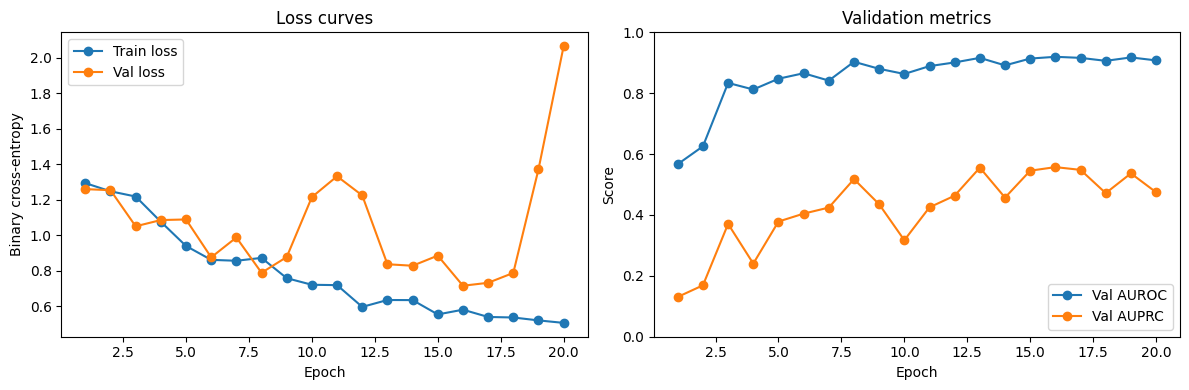

In [49]:
history = results["history"]
plot_training_curves(history)

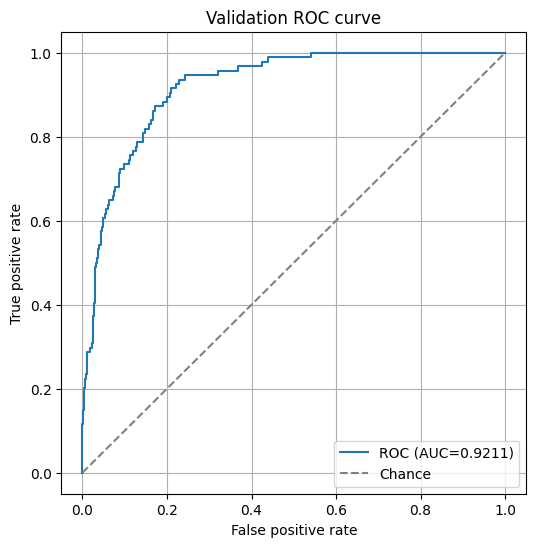

In [50]:
roc_data = results["roc"]
plot_roc(roc_data["labels"], roc_data["scores"])

In [59]:
headers, seqs = read_fasta(fasta_path)

ds_tr, ds_val, ds_te = prepare_data(fasta_path, label_path, subset_size=6000, random_state=42)
loader = DataLoader(ds_te, batch_size=8, shuffle=False, num_workers=0, collate_fn=collate_pad)

all_headers, all_probs, all_logits = [], [], []

model.eval()
with torch.no_grad():
    for hdr_batch, X, mask, Y in tqdm(loader, desc="Val", leave=False):
        X = X.to(device, dtype=torch.float32)
        mask = mask.to(device)
        logits = model(X, mask)        # (B,) for binary or (B, n_classes) for multi
        probs = torch.sigmoid(logits)  # or softmax for multi
        all_logits.append(logits.cpu().numpy())
        all_headers.extend(hdr_batch)
        all_probs.append(probs.cpu().numpy())

all_probs = np.concatenate(all_probs)
all_logits = np.concatenate(all_logits)

# Example: show top 10 “most positive” sequences
top_idx = np.argsort(-all_probs)[:10]
for i in top_idx:
    print(all_headers[i], all_probs[i], )

Using random subset of 6000 sequences (from 135751) with random_state=42.


Val:   0%|          | 0/150 [00:00<?, ?it/s]

Unknown_348-fGymBra#Unknown 0.45236838
Unknown_295-fAstCal#Unknown 0.45235085
L1_16-mDugDug#LINE/L1 0.45231384
Unknown_24-fOsmEpe#Unknown 0.4523093
Unknown_23-fMelBoe#DNA 0.45230842
L1_48-mEptNil#LINE/L1 0.45230725
Unknown_827-fPorCra#Unknown 0.45230642
Unknown_232-fNeoGra#Unknown 0.45229843
L1_39-mTalEur#LINE/L1 0.4522978
L1_31-mTalEur#LINE/L1 0.45229018


In [61]:
auroc, auprc, te_loss, te_scores, te_labels = evaluate(model, loader, nn.BCEWithLogitsLoss(), device, ds_te)
print(f"Test set performance: Loss {te_loss:.4f} | AUROC {auroc:.4f} | AUPRC {auprc:.4f}")

Val:   0%|          | 0/150 [00:00<?, ?it/s]

Test set performance: Loss 0.6163 | AUROC 0.4896 | AUPRC 0.0735


In [57]:
model.eval()
all_logits = []
with torch.no_grad():
    for _, X, mask, Y in tqdm(loader, desc="Val", leave=False):
        X = X.to(device, dtype=torch.float32)
        mask = mask.to(device)
        logits = model(X, mask)
        all_logits.append(logits.cpu().numpy())
all_logits = np.concatenate(all_logits)
print("logits mean/std/min/max:",
      all_logits.mean(), all_logits.std(),
      all_logits.min(), all_logits.max())

Val:   0%|          | 0/750 [00:00<?, ?it/s]

logits mean/std/min/max: -0.19325908 0.0007944428 -0.2001337 -0.1893031


In [52]:
ds_tr

In [53]:
label_dict = load_labels(label_path)
labels = [label_dict[h] for h in headers]

for i in range(30):
    print(all_headers[i], all_probs[i], labels[i])

TcMar-Tc1_2-fSynAcu#DNA/TcMar-Tc1 0.45195186 1.0
hAT_1-bLepDis#Unknown 0.45163184 1.0
Unknown_8-rCycPin#Unknown 0.45211476 1.0
Unknown_63-aPelLes#Unknown 0.45163652 1.0
L1_17-rThaEle#LINE/L1 0.45191637 1.0
Unknown_530-fGobGob#Unknown 0.4519955 0.0
Unknown_30-fHypImm#Unknown 0.451854 1.0
Unknown_56-bPasDom#Unknown 0.4516484 1.0
Unknown_537-fNanAnt#Unknown 0.451801 1.0
DIRS_441-rBraPum#LTR/DIRS 0.45156902 1.0
Unknown_418-fNanAch#Unknown 0.4519096 1.0
hAT_148-fPorCra#DNA 0.4520601 0.0
hAT_420-aEngPus#DNA/hAT 0.45178458 1.0
L1_156-aRanTem#LINE/L1 0.45181438 1.0
Unknown_90-fThaAma#Unknown 0.45190352 1.0
Unknown_706-aBomVar#DNA 0.45175952 1.0
Gypsy_75-rEulEur#LTR/Gypsy 0.45156726 1.0
Gypsy_23-rPodMel#LTR/Gypsy 0.4517302 1.0
TcMar-Tc1_21-fNeoGra#DNA/TcMar-Tc1 0.45212686 1.0
hAT_5-kMyxGlu#Unknown 0.45184344 0.0
Unknown_4-mPonAbe#Unknown 0.45172057 0.0
Unknown_83-mMusNiv#Unknown 0.45163047 1.0
TcMar-Tc1_6-fLetNeb#DNA/TcMar-Tc1 0.45191914 1.0
Gypsy_48-aHylSar#LTR/Gypsy 0.45163652 1.0
DIRS_8-bAma

In [56]:
min(all_probs), max(all_probs)

(0.45013288, 0.45281506)

In [34]:
headers, sequences = read_fasta(fasta_path)
label_dict = load_labels(label_path)
labels = [label_dict[h] for h in headers]

total_sequences = len(sequences)
if subset_size is not None and subset_size < total_sequences:
    rng = np.random.default_rng(42)
    perm = rng.permutation(total_sequences)
    sel_idx = np.sort(perm[:subset_size])
    headers = [headers[i] for i in sel_idx]
    sequences = [sequences[i] for i in sel_idx]
    labels = [labels[i] for i in sel_idx]
    print(f"Using random subset of {len(headers)} sequences (from {total_sequences}) with random_state={42}.")
else:
    print(f"Using all {total_sequences} sequences for training.")

idx_tr, idx_te = train_test_split(
    np.arange(len(sequences)), test_size=0.2, train_size=0.6, stratify=labels, random_state=42
)
idx_val = np.setdiff1d(np.arange(len(sequences)), np.concatenate([idx_tr, idx_te]))
ds_tr = SeqDataset([headers[i] for i in idx_tr], [sequences[i] for i in idx_tr], [labels[i] for i in idx_tr])
ds_val = SeqDataset([headers[i] for i in idx_te], [sequences[i] for i in idx_te], [labels[i] for i in idx_te])
ds_te = SeqDataset([headers[i] for i in idx_val], [sequences[i] for i in idx_val], [labels[i] for i in idx_val])

Using random subset of 6000 sequences (from 135751) with random_state=42.


In [41]:
len(label_dict)

135751

In [39]:
len(labels), sum(labels)

(6000, 469.0)

# Multi-class extension

Key changes:
- Labels become integer class IDs and we train with **`CrossEntropyLoss`** (softmax is handled implicitly).
- RC invariance is enforced in the **feature vector space** (two passes through a shared tower: forward sequence and reverse-complement sequence; then sum/average pooled feature vectors).
- For the typical strong class imbalance, we compute **class weights** from the training split and pass them to the loss.


In [1]:
import numpy as np
from pathlib import Path

def load_multiclass_labels(label_path):
    '''
    Parse a label file into a dict: header -> tag (string).

    Expected formats (either works):
      1) <header>\t<tag>
      2) <header> <tag> [other columns ignored]
    '''
    label_path = Path(label_path)
    d = {}
    with label_path.open("r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split()
            if len(parts) < 2:
                continue
            header, tag = parts[0], parts[1]
            d[header] = tag
    return d

def build_class_map(tags, none_tag="None"):
    '''
    Build stable mapping tag -> class_id with none_tag at 0 (if present).
    '''
    uniq = sorted(set(tags))
    if none_tag in uniq:
        uniq.remove(none_tag)
        class_names = [none_tag] + uniq
    else:
        class_names = uniq
    tag_to_id = {t:i for i,t in enumerate(class_names)}
    return tag_to_id, class_names

def compute_class_weights(y_ids, n_classes, mode="inv_sqrt", eps=1e-6):
    '''
    Class weights for imbalanced single-label multi-class.
      - inv:      1/freq
      - inv_sqrt: 1/sqrt(freq)  (usually less extreme)
      - none:     uniform weights
    '''
    counts = np.bincount(np.asarray(y_ids, dtype=np.int64), minlength=n_classes).astype(np.float64)
    if mode == "none":
        w = np.ones(n_classes, dtype=np.float32)
    elif mode == "inv":
        w = 1.0 / (counts + eps)
    elif mode == "inv_sqrt":
        w = 1.0 / np.sqrt(counts + eps)
    else:
        raise ValueError(f"Unknown mode={mode}")
    w = w / (w.mean() + 1e-12)
    return w.astype(np.float32)


In [2]:
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F

# Channel order is assumed to be: A,C,G,T,N  (5 channels)
REV_COMP = torch.tensor([3, 2, 1, 0, 4], dtype=torch.long)

class SeqDatasetMC(Dataset):
    def __init__(self, headers, sequences, label_ids):
        self.headers = list(headers)
        self.sequences = list(sequences)
        self.label_ids = np.asarray(label_ids, dtype=np.int64)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.headers[idx], self.sequences[idx].encode("ascii", "ignore"), int(self.label_ids[idx])

def collate_pad_mc(batch):
    '''
    Batch -> (headers, X, mask, Y)
      - X:   float32 tensor (B, 5, Lmax) one-hot (A,C,G,T,N)
      - mask:bool tensor   (B, Lmax) True where the position is a real base AND not N
      - Y:   long tensor   (B,) class IDs for CrossEntropyLoss
    '''
    headers, seq_bytes, y_ids = zip(*batch)

    idx_list = [ENCODE[np.frombuffer(sb, dtype=np.uint8)] for sb in seq_bytes]
    max_len = max(x.size for x in idx_list)

    B = len(idx_list)
    X = torch.zeros((B, 5, max_len), dtype=torch.float32)
    mask = torch.zeros((B, max_len), dtype=torch.bool)

    for i, idx_np in enumerate(idx_list):
        idx = torch.from_numpy(idx_np.astype(np.int64))
        L = idx.numel()
        pos = torch.arange(L, dtype=torch.long)
        X[i, idx, pos] = 1.0
        mask[i, :L] = (idx != 4)

    Y = torch.tensor(y_ids, dtype=torch.long)
    return list(headers), X, mask, Y


In [3]:
class ConvBlock(nn.Module):
    def __init__(self, c_in, c_out, kernel_size=9, dilation=1, dropout=0.1):
        super().__init__()
        assert kernel_size % 2 == 1
        pad = (kernel_size // 2) * dilation
        self.conv = nn.Conv1d(c_in, c_out, kernel_size, padding=pad, dilation=dilation, bias=True)
        self.bn = nn.BatchNorm1d(c_out)
        self.drop = nn.Dropout(dropout)
        self.proj = nn.Identity() if c_in == c_out else nn.Conv1d(c_in, c_out, 1)

    def forward(self, x):
        y = self.conv(x)
        y = F.gelu(self.bn(y))
        y = self.drop(y)
        return y + self.proj(x)

class MaskedMaxPool1d(nn.Module):
    def __init__(self, kernel_size=2, stride=2):
        super().__init__()
        self.pool = nn.MaxPool1d(kernel_size, stride=stride)

    def forward(self, x, mask):
        x_p = self.pool(x)
        if mask is None:
            return x_p, None
        m = mask.float().unsqueeze(1)  # (B,1,L)
        m_p = self.pool(m).squeeze(1) > 0.0
        return x_p, m_p

def masked_avg_pool(z, mask):
    if mask is None:
        return z.mean(-1)
    m = mask.unsqueeze(1).float()
    return (z * m).sum(-1) / m.sum(-1).clamp_min(1.0)

class RCCNN_Tower_Multiclass(nn.Module):
    '''
    Supervisor-style RC invariance:
        pooled(x) + pooled(RC(x))  (shared tower weights)
    Then an MLP head to num_classes logits.
    '''
    def __init__(self, num_classes, width=128, motif_kernels=(7, 15), context_kernel=9, context_dilations=(1,2,4), dropout=0.1):
        super().__init__()
        self.num_classes = int(num_classes)

        self.motif_convs = nn.ModuleList([
            nn.Conv1d(5, width, kernel_size=k, padding=(k//2), bias=True)
            for k in motif_kernels
        ])
        self.motif_bn = nn.ModuleList([nn.BatchNorm1d(width) for _ in motif_kernels])
        self.motif_drop = nn.Dropout(dropout)

        in_ch = width * len(motif_kernels)
        self.mix = nn.Sequential(
            nn.Conv1d(in_ch, width, kernel_size=1, bias=True),
            nn.BatchNorm1d(width),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.blocks = nn.ModuleList([
            ConvBlock(width, width, kernel_size=context_kernel, dilation=d, dropout=dropout)
            for d in context_dilations
        ])
        self.pool = MaskedMaxPool1d(kernel_size=2, stride=2)

        self.head = nn.Sequential(
            nn.Linear(width, 256),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(256, self.num_classes),
        )

    @staticmethod
    def rc_transform(x, mask):
        x_rc = x.index_select(1, REV_COMP.to(x.device)).flip(-1)
        mask_rc = None if mask is None else mask.flip(-1)
        return x_rc, mask_rc

    def tower(self, x, mask):
        feats = []
        for conv, bn in zip(self.motif_convs, self.motif_bn):
            y = conv(x)
            y = self.motif_drop(F.gelu(bn(y)))
            feats.append(y)
        z = torch.cat(feats, dim=1)   # (B, width*K, L)
        z = self.mix(z)               # (B, width, L)

        m = mask
        for blk in self.blocks:
            z = blk(z)
            z, m = self.pool(z, m)
        return masked_avg_pool(z, m)  # (B,width)

    def forward(self, x, mask):
        f = self.tower(x, mask)
        x_rc, mask_rc = self.rc_transform(x, mask)
        r = self.tower(x_rc, mask_rc)
        pooled = 0.5 * (f + r)
        return self.head(pooled)      # logits (B,num_classes)


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report
from sklearn.metrics import roc_auc_score, average_precision_score
import math

def run_train_multiclass(
    fasta_path, label_path,
    batch_size=8, epochs=20, lr=1e-3,
    width=128, motif_kernels=(7,15), context_kernel=9, context_dilations=(1,2,4),
    device=None, patience=6, subset_size=None, random_state=42,
    weight_mode="inv_sqrt"
):
    device = resolve_device(device)
    print(f"Using device: {device}")

    headers, sequences = read_fasta(fasta_path)
    lab = load_multiclass_labels(label_path)

    filtered_h, filtered_s, tags = [], [], []
    missing = 0
    for h, s in zip(headers, sequences):
        t = lab.get(h)
        if t is None:
            missing += 1
            continue
        filtered_h.append(h)
        filtered_s.append(s)
        tags.append(t)
    if missing:
        print(f"Dropped {missing} sequences without labels.")

    n_total = len(filtered_h)
    if subset_size is not None and subset_size < n_total:
        rng = np.random.default_rng(random_state)
        sel = np.sort(rng.permutation(n_total)[:subset_size])
        filtered_h = [filtered_h[i] for i in sel]
        filtered_s = [filtered_s[i] for i in sel]
        tags = [tags[i] for i in sel]
        print(f"Using random subset: {len(filtered_h)} / {n_total}")
    else:
        print(f"Using all labeled sequences: {n_total}")

    tag_to_id, class_names = build_class_map(tags, none_tag="None")
    y_ids = np.asarray([tag_to_id[t] for t in tags], dtype=np.int64)
    n_classes = len(class_names)
    print(f"Classes: {n_classes}. First few: {class_names[:min(10,n_classes)]}")

    idx_tr, idx_te = train_test_split(
        np.arange(len(filtered_s)), test_size=0.2, stratify=y_ids, random_state=random_state
    )

    ds_tr = SeqDatasetMC([filtered_h[i] for i in idx_tr], [filtered_s[i] for i in idx_tr], y_ids[idx_tr])
    ds_te = SeqDatasetMC([filtered_h[i] for i in idx_te], [filtered_s[i] for i in idx_te], y_ids[idx_te])

    loader_tr = DataLoader(ds_tr, batch_size=batch_size, shuffle=True, num_workers=0, collate_fn=collate_pad_mc)
    loader_te = DataLoader(ds_te, batch_size=batch_size, shuffle=False, num_workers=0, collate_fn=collate_pad_mc)

    w = compute_class_weights(y_ids[idx_tr], n_classes, mode=weight_mode)
    w_t = torch.tensor(w, dtype=torch.float32, device=device)
    loss_fn = nn.CrossEntropyLoss(weight=w_t)

    model = RCCNN_Tower_Multiclass(
        num_classes=n_classes, width=width,
        motif_kernels=motif_kernels, context_kernel=context_kernel,
        context_dilations=context_dilations
    ).to(device)

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_bal_acc": [], "val_macro_f1": []}
    best_state, best_epoch = None, None
    best_macro_f1 = -math.inf
    bad = 0

    for ep in range(1, epochs + 1):
        model.train()
        running = 0.0
        for _, X, mask, Y in loader_tr:
            X = X.to(device, dtype=torch.float32)
            mask = mask.to(device)
            Y = Y.to(device, dtype=torch.long)

            logits = model(X, mask)
            loss = loss_fn(logits, Y)

            opt.zero_grad()
            loss.backward()
            opt.step()

            running += loss.item() * X.size(0)

        train_loss = running / len(ds_tr)

        model.eval()
        val_running = 0.0
        all_logits, all_y = [], []
        with torch.no_grad():
            for _, X, mask, Y in loader_te:
                X = X.to(device, dtype=torch.float32)
                mask = mask.to(device)
                Y = Y.to(device, dtype=torch.long)

                logits = model(X, mask)
                loss = loss_fn(logits, Y)
                val_running += loss.item() * X.size(0)

                all_logits.append(logits.detach().cpu())
                all_y.append(Y.detach().cpu())

        val_loss = val_running / len(ds_te)
        logits_np = torch.cat(all_logits, dim=0).numpy()
        y_np = torch.cat(all_y, dim=0).numpy()
        pred = logits_np.argmax(axis=1)

        acc = accuracy_score(y_np, pred)
        bal_acc = balanced_accuracy_score(y_np, pred)
        macro_f1 = f1_score(y_np, pred, average="macro")

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(acc)
        history["val_bal_acc"].append(bal_acc)
        history["val_macro_f1"].append(macro_f1)

        print(f"Epoch {ep}: train {train_loss:.4f} | val {val_loss:.4f} | acc {acc:.4f} | bal_acc {bal_acc:.4f} | macroF1 {macro_f1:.4f}")

        if macro_f1 > best_macro_f1 + 1e-4:
            best_macro_f1 = macro_f1
            best_epoch = ep
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                print("Early stopping.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(device)

        ckpt = {
            "model_state_dict": best_state,
            "class_names": class_names,
            "tag_to_id": tag_to_id,
            "arch": {
                "width": width,
                "motif_kernels": tuple(motif_kernels),
                "context_kernel": int(context_kernel),
                "context_dilations": tuple(context_dilations),
            }
        }
        save_torch(ckpt, "vgp_model_data", "rc_tower_multiclass_best")
    else:
        ckpt = None

    model.eval()
    probs = torch.softmax(torch.tensor(logits_np), dim=1).numpy()

    print("\nValidation classification report:")
    print(classification_report(y_np, pred, target_names=class_names, zero_division=0))

    try:
        y_onehot = np.eye(n_classes, dtype=np.int32)[y_np]
        auroc_macro = roc_auc_score(y_onehot, probs, average="macro", multi_class="ovr")
        auprc_macro = average_precision_score(y_onehot, probs, average="macro")
        print(f"Val macro-AUROC (OVR): {auroc_macro:.4f} | macro-AUPRC: {auprc_macro:.4f}")
    except Exception as e:
        print(f"Skipping AUROC/AUPRC (multiclass) due to: {type(e).__name__}: {e}")

    return {
        "model": model,
        "history": history,
        "best_epoch": best_epoch,
        "best_macro_f1": best_macro_f1,
        "class_names": class_names,
        "tag_to_id": tag_to_id,
        "device": str(device),
        "checkpoint": ckpt,
    }


In [5]:
def predict_sequences_multiclass(model, sequences, batch_size=8, device=None):
    '''
    Predict class probabilities for arbitrary input sequences (strings).
    Returns (probs, pred_ids).
    '''
    device = resolve_device(device)
    model = model.to(device).eval()

    tmp_headers = [f"q{i}" for i in range(len(sequences))]
    tmp_labels = np.zeros(len(sequences), dtype=np.int64)  # dummy labels
    ds = SeqDatasetMC(tmp_headers, sequences, tmp_labels)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0, collate_fn=collate_pad_mc)

    probs_all = []
    with torch.no_grad():
        for _, X, mask, _ in loader:
            X = X.to(device, dtype=torch.float32)
            mask = mask.to(device)
            logits = model(X, mask)
            probs = torch.softmax(logits, dim=1).detach().cpu().numpy()
            probs_all.append(probs)
    probs_all = np.concatenate(probs_all, axis=0)
    pred_ids = probs_all.argmax(axis=1)
    return probs_all, pred_ids
